In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

RANDOM_STATE = 42

In [2]:
df_raw = pd.read_csv("heart_disease_uci.csv")
df_raw.columns = [c.strip().lower() for c in df_raw.columns]

if 'thalch' in df_raw.columns and 'thalach' not in df_raw.columns:
    df_raw.rename(columns={'thalch': 'thalach'}, inplace=True)

cols_to_drop = [c for c in ['id', 'dataset'] if c in df_raw.columns]
df = df_raw.drop(columns=cols_to_drop).copy()

df.replace("?", np.nan, inplace=True)
print("Dataset Shape after column normalization:", df.shape)

Dataset Shape after column normalization: (920, 14)


In [3]:
if 'num' in df.columns:
    df['target'] = (df['num'] > 0).astype(int)
    df.drop(columns=['num'], inplace=True)

X = df.drop(columns=["target"])
y = df["target"].astype(int)
TARGET_COL = df["target"].astype(int)
NUMERIC_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
CATEGORICAL_COLS = [c for c in X.columns if c not in NUMERIC_COLS]

for col in NUMERIC_COLS:
    X[col] = pd.to_numeric(X[col], errors='coerce')

for col in CATEGORICAL_COLS:
    X[col] = X[col].astype(str).replace({'nan': np.nan, 'None': np.nan})

In [4]:
missing_audit = pd.DataFrame({
    'Missing Count': X.isnull().sum(),
    'Missing Percentage (%)': (X.isnull().mean() * 100).round(2)
})
print("--- Missing Values Audit ---")
display(missing_audit[missing_audit['Missing Count'] > 0])

print("\n--- Target Distribution ---")
class_dist = y.value_counts(normalize=True).round(3) * 100
print(f"Healthy (0): {y.value_counts()[0]} ({class_dist[0]:.1f}%)")
print(f"Disease (1): {y.value_counts()[1]} ({class_dist[1]:.1f}%)")

--- Missing Values Audit ---


,Missing Count,Missing Percentage (%)
trestbps,59,6.41
chol,30,3.26
fbs,90,9.78
restecg,2,0.22
thalach,55,5.98
exang,55,5.98
oldpeak,62,6.74
slope,309,33.59
ca,611,66.41
thal,486,52.83



--- Target Distribution ---
Healthy (0): 411 (44.7%)
Disease (1): 509 (55.3%)


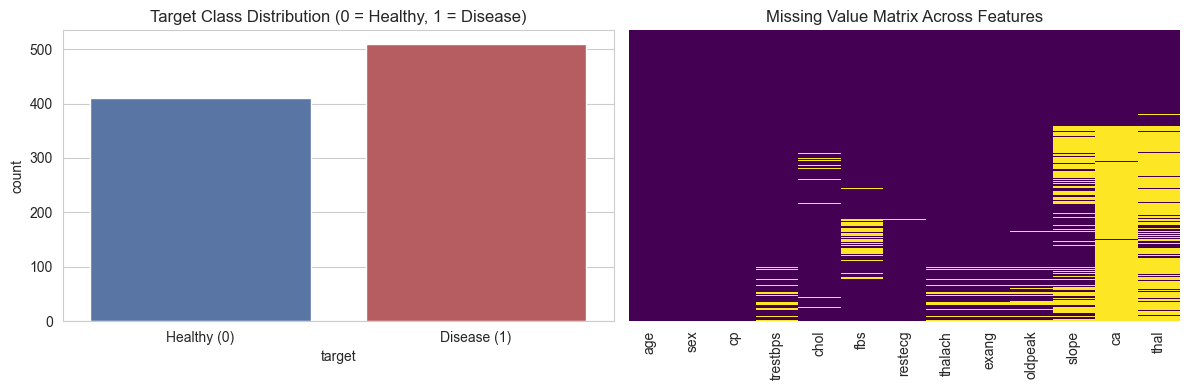

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y, ax=axes[0], palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Target Class Distribution (0 = Healthy, 1 = Disease)")
axes[0].set_xticklabels(["Healthy (0)", "Disease (1)"])

sns.heatmap(X.isnull(), cbar=False, cmap="viridis", yticklabels=False, ax=axes[1])
axes[1].set_title("Missing Value Matrix Across Features")

plt.tight_layout()
plt.show()

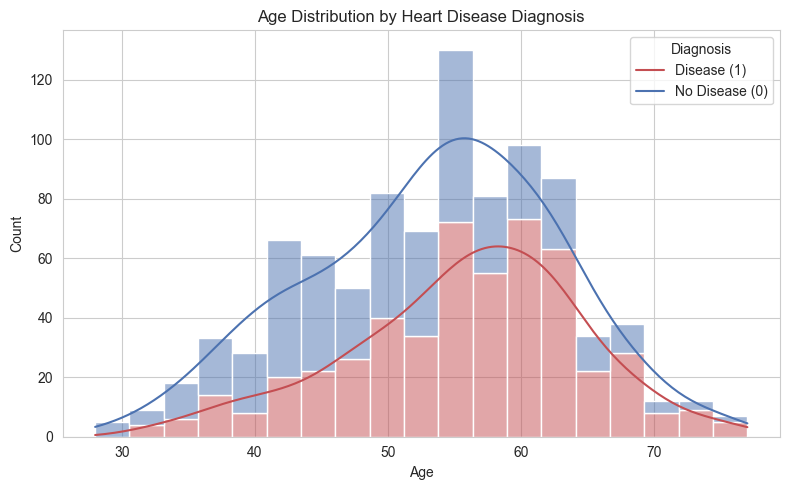

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue=TARGET_COL, multiple='stack', palette=["#4C72B0", "#C44E52"], kde=True)
plt.title("Age Distribution by Heart Disease Diagnosis")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(title="Diagnosis", labels=["Disease (1)", "No Disease (0)"])
plt.tight_layout()
plt.show()

In [7]:
def sanitize_cholesterol(df_in):
    df_out = df_in.copy()
    if 'chol' in df_out.columns:
        df_out['chol'] = df_out['chol'].replace(0, np.nan)
    return df_out

num_pipeline = Pipeline([
    ("clean_zeros", FunctionTransformer(sanitize_cholesterol, feature_names_out="one-to-one")),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, NUMERIC_COLS),
        ("cat", cat_pipeline, CATEGORICAL_COLS)
    ],
    remainder="drop"
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Holdout test set: {X_test.shape[0]} samples")

In [ ]:
dt = DecisionTreeClassifier(max_depth=4, min_samples_split=10, class_weight="balanced", random_state=RANDOM_STATE)
rf = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=3, class_weight="balanced", random_state=RANDOM_STATE)
gnb = GaussianNB()

ensemble = VotingClassifier(
    estimators=[("dt", dt), ("rf", rf), ("gnb", gnb)],
    voting="soft",
    weights=[1, 2, 1]
)

full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("ensemble", ensemble)
])

full_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('ensemble', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

ROC-AUC Score: 0.896

Classification Report:
               precision    recall  f1-score   support

     Healthy       0.79      0.82      0.80        82
     Disease       0.85      0.82      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



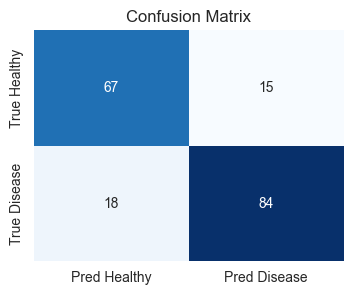

In [10]:
y_pred = full_pipeline.predict(X_test)
y_probs = full_pipeline.predict_proba(X_test)[:, 1]

print("ROC-AUC Score:", round(roc_auc_score(y_test, y_probs), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Healthy", "Disease"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred Healthy", "Pred Disease"],
            yticklabels=["True Healthy", "True Disease"])
plt.title("Confusion Matrix")
plt.show()

In [14]:
import pandas as pd
import joblib

# 1. Load the saved pipeline
# Ensure the filename matches what you used in the generation step

# 2. Create a manual test case (Sample Patient)
# This mimics a single row of raw data from the UCI dataset
sample_patient = pd.DataFrame([{
    "age": 67,
    "sex": 1,            # 1 = male, 0 = female
    "cp": 4,             # Chest pain type (1-4 in raw data)
    "trestbps": 160,     # Resting blood pressure (mm Hg)
    "chol": 286,         # Serum cholesterol (mg/dl)
    "fbs": 0,            # Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
    "restecg": 2,        # Resting ECG results (0-2)
    "thalach": 108,      # Max heart rate achieved
    "exang": 1,          # Exercise-induced angina (1 = yes, 0 = no)
    "oldpeak": 1.5,      # ST depression induced by exercise
    "slope": 2,          # Slope of peak exercise ST segment (1-3)
    "ca": 3,             # Major vessels colored by fluoroscopy (0-3)
    "thal": 3            # Thalassemia type (3 = normal, 6 = fixed, 7 = reversable)
}])

# 3. Run Prediction
prediction = full_pipeline.predict(sample_patient)[0]
probabilities = full_pipeline.predict_proba(sample_patient)[0]

# 4. Display Results
print("--- Manual Test Results ---")
print(f"Prediction: {'Disease' if prediction == 1 else 'Healthy'}")
print(f"Confidence (Disease): {probabilities[1] * 100:.2f}%")
print(f"Confidence (Healthy): {probabilities[0] * 100:.2f}%")
if probabilities[0] >probabilities[1]:
    print ("not a HCL patient")
    
else :
    print("HCL patient")    




--- Manual Test Results ---
Prediction: Disease
Confidence (Disease): 50.12%
Confidence (Healthy): 49.88%
HCL patient


In [ ]:
sample_patient = X_test.iloc[[0]]
prediction = full_pipeline.predict(sample_patient)[0]
confidence = full_pipeline.predict_proba(sample_patient)[0][1]

print(f"Manual Test Prediction: {'Disease' if prediction == 1 else 'Healthy'} (Confidence: {confidence:.2f})")

joblib.dump(full_pipeline, "heart_disease_decision_support.pkl")
print("\nPipeline exported to 'heart_disease_decision_support.pkl'")